<a href="https://www.kaggle.com/code/sujalponnaluri/credit-card-fraud-detection?scriptVersionId=321858604" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
fraud_df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
fraud_df.shape
fraud_df.info()
fraud_df.isnull().sum()
fraud_df['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Class
0    284315
1       492
Name: count, dtype: int64

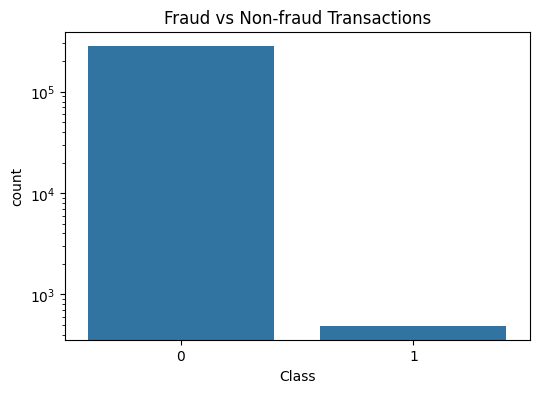

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=fraud_df)

plt.title("Fraud vs Non-fraud Transactions")
plt.yscale("log")

plt.show()

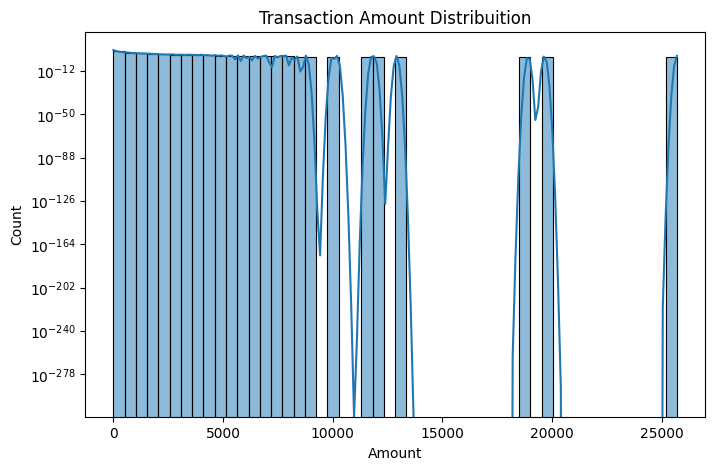

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(fraud_df['Amount'], bins=50, kde=True)

plt.yscale('log')

plt.title("Transaction Amount Distribuition")

plt.show()

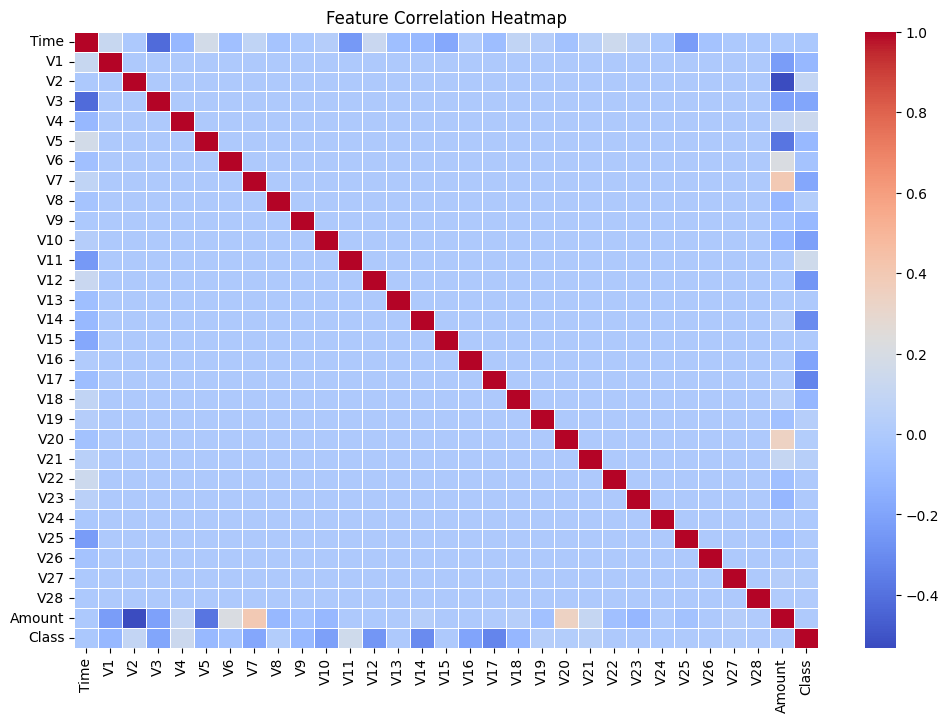

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(fraud_df.corr(), cmap='coolwarm', linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

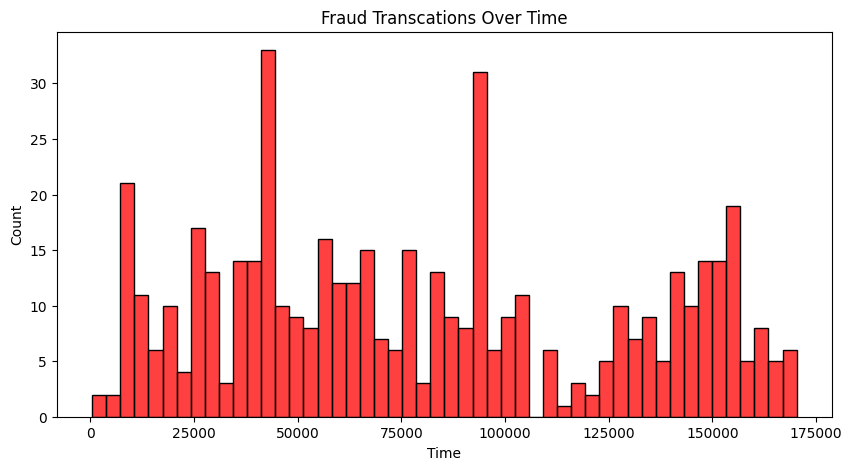

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    fraud_df[fraud_df['Class'] == 1]['Time'],
    bins=50,
    color='red'  
)

plt.title("Fraud Transcations Over Time")

plt.show()

In [9]:
scaler = StandardScaler()
fraud_df['Amount'] = scaler.fit_transform(fraud_df['Amount'].values.reshape(-1,1))
fraud_df['Time'] = scaler.fit_transform(fraud_df['Time'].values.reshape(-1,1))

In [10]:
X = fraud_df.drop('Class', axis=1)
y = fraud_df['Class']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [13]:
y_preds = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

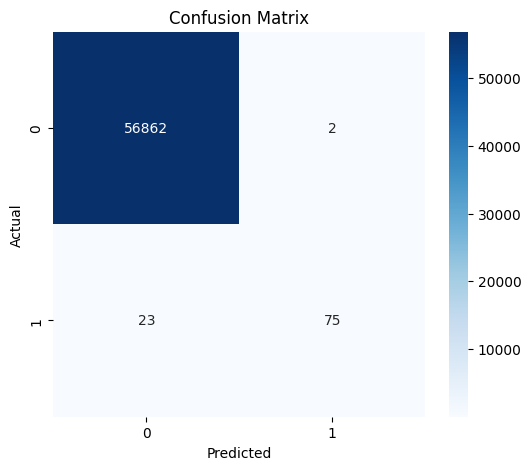

In [14]:
cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [15]:
print(classification_report(y_test, y_preds))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.77      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962



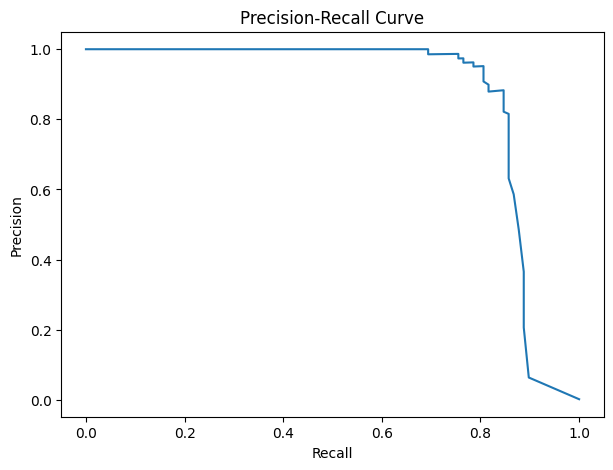

In [16]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.title("Precision-Recall Curve")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.show()

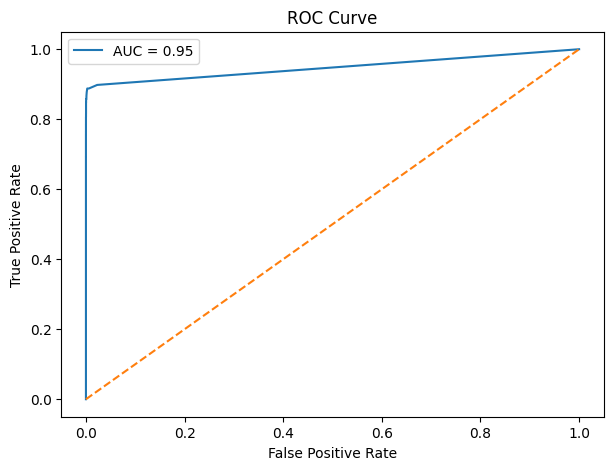

In [17]:
fpr, tpr,_ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], '--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

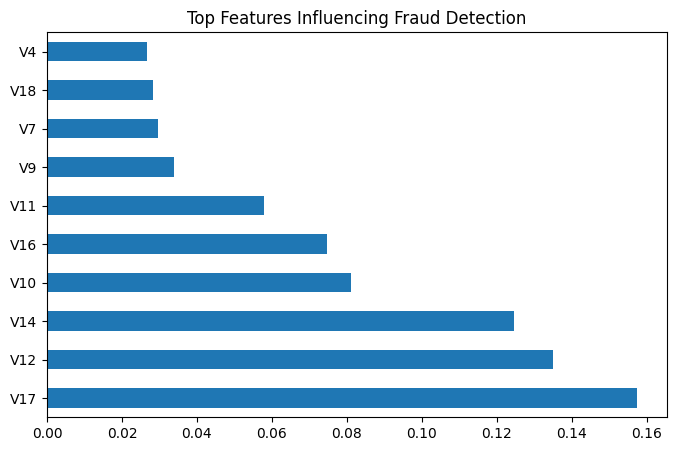

In [18]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh', figsize=(8,5))

plt.title("Top Features Influencing Fraud Detection")

plt.show()

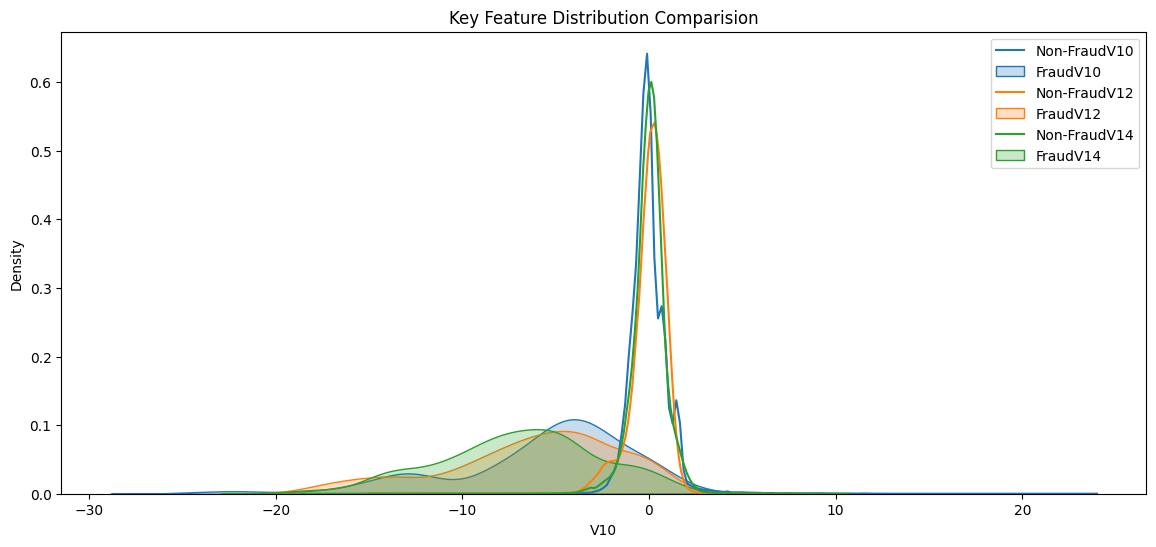

In [19]:
features = ['V10', 'V12', 'V14']

plt.figure(figsize=(14, 6))

for col in features:
    sns.kdeplot(
        fraud_df[fraud_df['Class']==0][col],
        label=f'Non-Fraud{col}',
        fill=False
    )
    sns.kdeplot(
        fraud_df[fraud_df['Class']== 1][col],
        label=f'Fraud{col}',
        fill=True
    )
plt.title("Key Feature Distribution Comparision")

plt.legend()

plt.show()

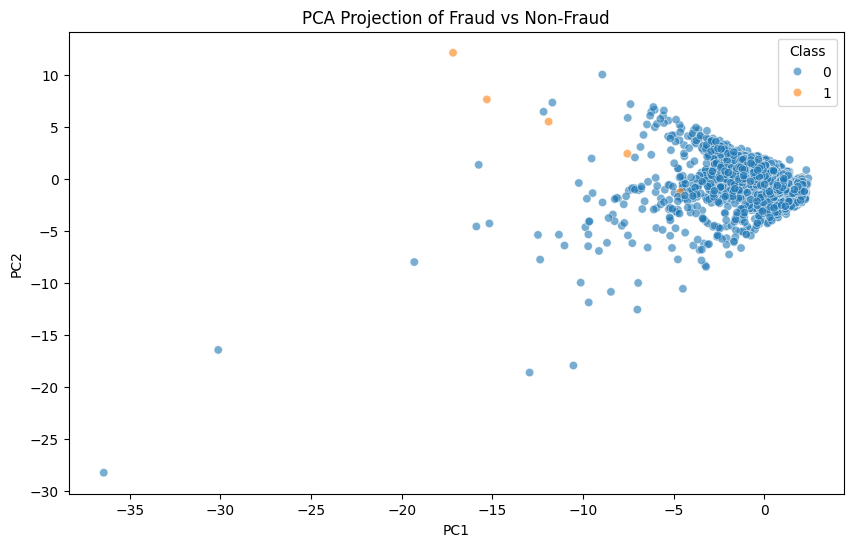

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = y.values

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df.sample(5000),
    x='PC1',
    y='PC2',
    hue='Class',
    alpha=0.6
)

plt.title("PCA Projection of Fraud vs Non-Fraud")

plt.show()